In [1]:
%matplotlib tk

In [2]:
import dnois
from dnois.optics import rt
import matplotlib.pyplot as plt
import torch

from polysurf import ExtendedPolynomial

In [3]:
torch.set_default_dtype(torch.double)
torch.set_grad_enabled(False)
torch.set_printoptions(precision=10)

In [4]:
dnois.set_default('length', 'mm')
dnois.set_default('angle', 'deg')
dnois.ext.zmx.load_agf('CHINA.agf')

In [5]:
def apply_tilt_x(context, angle):
    context.phi = 90
    context.theta = -angle
    context.chi = -90

In [25]:
sq = rt.SurfaceSequence([
    rt.Plane(aperture=31.675),
    rt.Plane(aperture=24.424, z=80),
    ExtendedPolynomial(
        -613.98, 18.807, [0., 0., -2.35, 0., -2.664, 0., 0.126, 0., 0.096, 0.148, 0., 0.2840, 0., 0.139],
        aperture=rt.RectangularAperture(21 * 2, 20 * 2, center_y=29),
        norm_radius=50,
        reflective=True,
        y=-27.67,
        z=55,
    ),
    rt.Conic(-71.19, 1.645, aperture=8.2, reflective=True, y=5.12, z=-55),
    ExtendedPolynomial(
        -60.58, -0.523, [0., 0., 6.668, 0., 6.906, 0., 0.03, 0., 0.032, 0.354, 0., 0.762, 0., 0.424],
        aperture=rt.RectangularAperture(22.5 * 2, 21.5 * 2, center_y=-19.9),
        norm_radius=50,
        reflective=True,
        y=2.03 - 5.12,
        z=55,
    ),
    rt.Plane(aperture=10.004, y=-2.03 - 16.147, z=-55),
    rt.Plane('K9', rt.RectangularAperture(8.95 * 2, 8.5 * 2), z=-18.048),
    rt.Plane(aperture=rt.RectangularAperture(8.95 * 2, 8.5 * 2), z=-0.7),
    rt.Plane(aperture=rt.RectangularAperture(4.4 * 2, 3.7 * 2), z=-0.4),  #IMAGE
])
sq.all_relative_()
apply_tilt_x(sq[2].context, -11.74)
apply_tilt_x(sq[5].context, 1.92)

for idx in [3, 5, 6, 7, 8]:
    sq[idx].context.upward_in = False

In [35]:
optics = rt.OffAxisRayTracing(sq, dnois.PixelGrid(256, 0.1e-3), wl=0.7e-3)
optics.psf_model.psf_center = 'mean'

In [8]:
optics.plot_3d((0., 0.))

In [36]:
psf = optics.psf()

In [37]:
psf = torch.sqrt(psf / psf.max())
plt.imshow(psf.squeeze().numpy())

In [38]:
%matplotlib inline

SRTSpotDiagram(fig=<Figure size 500x500 with 1 Axes>, rms=tensor([0.0011673300]), geo_radius=tensor([0.0031774053]))

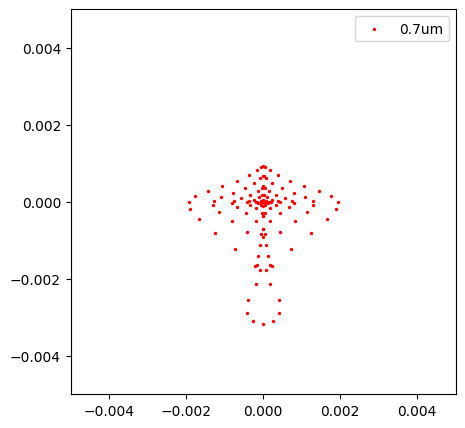

In [39]:
spot_diagram = optics.plot_spot_diagram(
    optics.fovd2obj([(0, 0)], optics.depth),
    # ending_surface=7,
    width=0.01,
    entr_d=23,
    entr_z=228.791,
)
spot_diagram